<a href="https://colab.research.google.com/github/Pema-Codes/pytorch-learning/blob/main/01_pytorch_tensors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
import numpy as np

#Initializing a Tensor (Creation)

I will show you different ways to summon a Tensor into existence.

##1. Directly from raw data or numpy array

In [4]:
data = [[1,2],[3,4]]
x_data = torch.tensor(data)

In [5]:
#Tensors can be created from NumPy arrays.
np_arrays = np.array(data)
x_np = torch.from_numpy(np_arrays)

##2. From Another Tensors: Copycat Tensors (_like)

In [6]:
#copies its shape (e.g., 2x2) and data type, but fills it entirely with 1s.
#retains the properties of x_data
x_ones = torch.ones_like(x_data)
print(f"Ones Tensor: \n {x_ones} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 



In [7]:
#torch.rand_like does the same but fills it with random numbers.
#overrides the datatype of x_data

x_rand = torch.rand_like(x_data, dtype = torch.float)
print(f"Random Tensor: \n {x_rand} \n")

Random Tensor: 
 tensor([[0.6767, 0.4193],
        [0.8917, 0.9643]]) 



##3. Brand New Tensors from Scratch

You pass a shape tuple (like (2,3), meaning 2 rows and 3 columns) to torch.rand(), torch.ones(), or torch.zeros().


In [8]:
#shape is a tuple of tensor dimensions.
shape = (3,3)

rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zero_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zero_tensor} \n")


Random Tensor: 
 tensor([[0.0328, 0.9642, 0.5126],
        [0.9578, 0.6697, 0.9068],
        [0.8746, 0.6074, 0.8876]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]) 



#2. Atrributes & Operations (Reading & Moving)

Once you have a tensor, you need to know what it is, where it lives, and how to change its position.

##Tensor Attributes

Every Tensor has three basic identity markers:
1. Shape: How big is it? (e.g., torch.Size([3, 4]) means 3 rows, 4 columns).

2. Datatype (dtype): What kind of numbers are inside? (e.g., float32 means decimals).

3. Device: Where does it physically live? (cpu or an accelerator like cuda/mps).

In [9]:
tensor = torch.rand(4,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Data type of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([4, 4])
Data type of tensor: torch.float32
Device tensor is stored on: cpu


In [10]:
tensor = torch.rand(28,28)

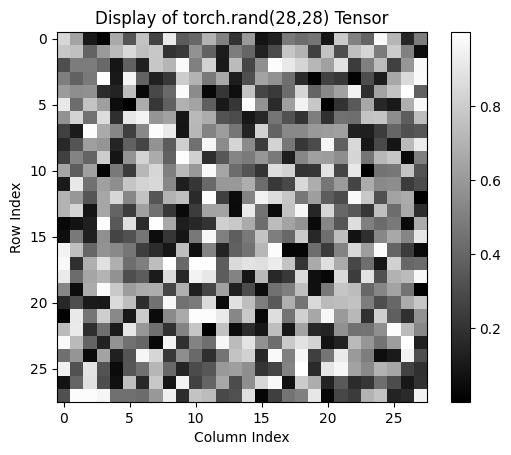

In [11]:

import matplotlib.pyplot as plt

# Convert the PyTorch tensor to a NumPy array for matplotlib
# Ensure the tensor is on the CPU before converting to NumPy
numpy_tensor = tensor.cpu().numpy()

# Display the tensor as an image
plt.imshow(numpy_tensor, cmap='gray') # Using 'gray' colormap for a 2D array
plt.title('Display of torch.rand(28,28) Tensor')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.colorbar() # Add a color bar to show intensity scale
plt.show()

### Drawing a white square in the middle


White square drawn from index 9 to 18 in both dimensions.


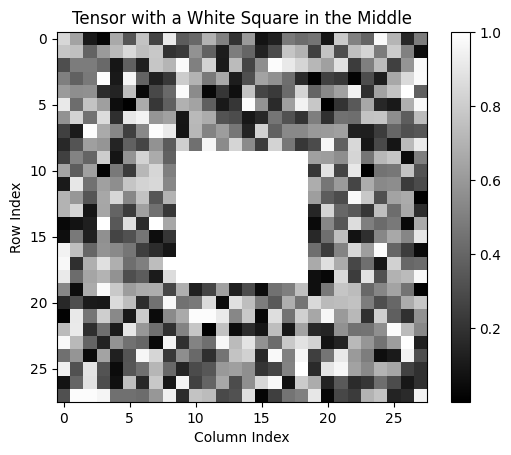

In [12]:
# Assuming numpy_tensor is already defined and is 28x28

# Define the dimensions of the square
square_size = 10

# Calculate the starting and ending indices for the square to be in the middle
start_index = (28 - square_size) // 2
end_index = start_index + square_size

# Set the values in the central slice to 1.0
numpy_tensor[start_index:end_index, start_index:end_index] = 1.0

print(f"White square drawn from index {start_index} to {end_index-1} in both dimensions.")

# Display the modified tensor
plt.imshow(numpy_tensor, cmap='gray')
plt.title('Tensor with a White Square in the Middle')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.colorbar()
plt.show()

## Creating a "Fake Color Image" by Stacking

Shape of the original ghost image: (28, 28)
Shape of the fake color image: (28, 28, 3)


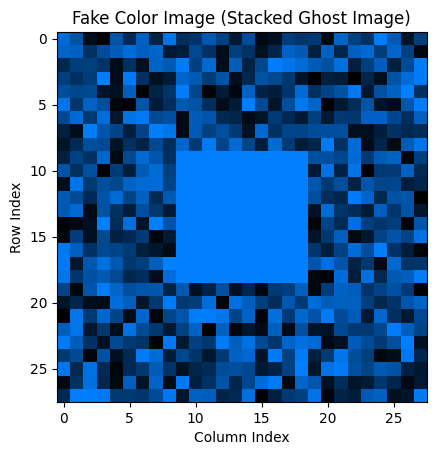

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Taking numpy_tensor from previous image as ghost image
# Stack the 2D numpy_tensor three times to create a 3-channel image
# The result will be a (height, width, 3) array
fake_color_image = np.stack([numpy_tensor*0, numpy_tensor*0.5, numpy_tensor*1], axis=-1)

print(f"Shape of the original ghost image: {numpy_tensor.shape}")
print(f"Shape of the fake color image: {fake_color_image.shape}")

# Display the fake color image
plt.imshow(fake_color_image)
plt.title('Fake Color Image (Stacked Ghost Image)')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()

#Transforming the shape of image data

The `shape_shifter` function is a utility designed to transform the shape of image data, specifically for preparing it for various machine learning model inputs. It takes an input `data` (expected to be an image array, like a NumPy array) and a `target_type` string, which dictates the desired output shape.

### Parameters:
- `data`: The input image data, typically a NumPy array with dimensions like `(height, width, channels)`.
- `target_type`: A string specifying the type of transformation to apply:
    - `"flatten"`: Transforms the image into a 1D array. For an image of shape `(H, W, C)`, it becomes `(H * W * C,)`.
    - `"batch"`: Adds a new dimension at the beginning, typically used to represent a batch of images where the batch size is 1. An image of shape `(H, W, C)` becomes `(1, H, W, C)`.
    - `"pytorch_style"`: Transposes the dimensions to match the PyTorch convention of `(Channels, Height, Width)`. An image of shape `(H, W, C)` becomes `(C, H, W)`.

In [14]:
def shape_shifter(data, target_type="flatten"):
    """
    Transform image data into different shapes.
    """
    if target_type == "flatten":
        # Turns (224, 224, 3) into (150528,)
        return data.flatten()

    elif target_type == "batch":
        # Adds a new dimension to the front (1, 224, 224, 3)
        # Often needed because AI models expect a batch, even if it's just 1 image!
        return np.expand_dims(data, axis=0)

    elif target_type == "pytorch_style":
        # Swaps (H, W, C) to (C, H, W)
        return np.transpose(data, (2, 0, 1))

Using the `shape_shifter` function with the `fake_color_image`.

In [22]:
print(f"Original `fake_color_image` shape: {fake_color_image.shape}")

# Flatten the image
flattened_image = shape_shifter(fake_color_image, target_type="flatten")
print(f"Flattened image shape: {flattened_image.shape}")

# Add a batch dimension
batched_image = shape_shifter(fake_color_image, target_type="batch")
print(f"Batched image shape: {batched_image.shape}")

# Convert to PyTorch style (C, H, W)
pytorch_style_image = shape_shifter(fake_color_image, target_type="pytorch_style")
print(f"PyTorch style image shape (C, H, W): {pytorch_style_image.shape}")

Original `fake_color_image` shape: (28, 28, 3)
Flattened image shape: (2352,)
Batched image shape: (1, 28, 28, 3)
PyTorch style image shape (C, H, W): (3, 28, 28)


## Moving to Accelerators

Tensors start on your CPU by default. You use tensor.to('cuda') (or torch.accelerator.current_accelerator()) to copy the data onto your GPU for fast processing (Use of .to method).

Copying large tensors across devices can be expensive in terms of time and memory!

In [15]:
if torch.accelerator.is_available():
  tensor = tensor.to(torch.accelerator.current_accelerator())

# Arithmetic & Operations

This is where you make tensors actually do things.

##Slicing and Indexing

In [16]:
tensor = torch.ones(4,4) #creates a tensor

#Access specific rows and columns using indexing
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[..., -1]}")

#Modify parts of the tensor
tensor[:,1] = 0
print(tensor)

First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


##Joining Tensors (Concatenation) torch.cat

You can use torch.cat to concatenate a sequence of tensors along a given dimension.

In [17]:
#join them horizontally (dim=1), vertically (dim=0)
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1)

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])


## Matrix Multiplication (@ or .matmul) vs. Element-wise (* or .mul)

`.matmul` is the method equivalent to the `@` operator.

In [18]:
#Matrix multiplication
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)

y3 = torch.rand_like(y1) #acts as a temporary placeholder
torch.matmul(tensor, tensor.T, out=y3)  #PyTorch overwrites the random numbers inside y3 with the final answer

#Element-wise multiplication
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.rand_like(tensor)
torch.mul(tensor, tensor, out=z3)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

Matrix multiplication:
@ or .matmul() performs matrix multiplication. Requires compatible dimensions for matrix algebra.

Instead of creating brand new Tensor in your computer's RAM to store the result, PyTorch overwrites the random numbers inside y3 with the final answer. This can save memory and computation time, especially with very large tensors or in loops.

Element-wise multiplication (also known as Hadamard product) * or .mul() multiplies corresponding elements of two tensors.
For this operation, the tensors must have compatible shapes for element-by-element operation.
Both lines create a brand-new tensor in your RAM to hold the result (z1 and z2).

##Extracting a single value (.item())

The line calculates the sum of all elements within the tensor and stores the result in a new tensor called `agg`.

 .item() method extracts that single numerical value from the tensor and returns it as a standard Python number (e.g., a float or an int).

In [19]:
agg = tensor.sum()
agg_item = agg.item()
print(agg_item, type(agg_item))

12.0 <class 'float'>


## In-place Operations

In-place operations modify the tensor's memory directly without creating a new copy. While it saves RAM, it wipes out the history of the tensor, which breaks PyTorch's Autograd (automatic differentiation).

In [20]:
print(f"{tensor} \n")
tensor.add_(5)
print(tensor)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]]) 

tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])


## Converting to NumPy Array

In [21]:
# To convert a tensor on the CPU to a NumPy array:
numpy_array = tensor.numpy()
print(f"NumPy array: {numpy_array}")
print(f"Type of NumPy array: {type(numpy_array)}")

# Modifying the NumPy array will also modify the original tensor on the CPU
numpy_array[0, 0] = 99
print(f"\nModified NumPy array: {numpy_array}")
print(f"Original tensor after NumPy modification: {tensor}")

NumPy array: [[6. 5. 6. 6.]
 [6. 5. 6. 6.]
 [6. 5. 6. 6.]
 [6. 5. 6. 6.]]
Type of NumPy array: <class 'numpy.ndarray'>

Modified NumPy array: [[99.  5.  6.  6.]
 [ 6.  5.  6.  6.]
 [ 6.  5.  6.  6.]
 [ 6.  5.  6.  6.]]
Original tensor after NumPy modification: tensor([[99.,  5.,  6.,  6.],
        [ 6.,  5.,  6.,  6.],
        [ 6.,  5.,  6.,  6.],
        [ 6.,  5.,  6.,  6.]])
